# 📊 Classification Metrics: A Complete Lecture Demo
## Accuracy · Precision · Recall · F1 Score · Specificity
### *with a deep-dive into WHY harmonic mean, not simple mean*

---

## 🗺️ Road Map
| # | Section |
|---|--------|
| 1 | The Confusion Matrix — the foundation |
| 2 | Accuracy — and why it can lie |
| 3 | Precision — quality of positive predictions |
| 4 | Recall — catching all positives |
| 5 | Precision vs Recall trade-off |
| 6 | **F1 Score + WHY Harmonic Mean? (Full Deep Dive)** |
| 7 | Specificity — the forgotten metric |
| 8 | All metrics side-by-side dashboard |
| 9 | Real model demo (Logistic Regression) |
| 10 | Decision guide + cheat sheet |
| 11 | Student exercise |

---

### 🏥 Running Scenario Throughout This Notebook

We use a **medical disease detection** setting to keep the stakes concrete:
- **Positive (1)** = Patient has the disease  
- **Negative (0)** = Patient is healthy  
- A classifier reads test results and outputs a prediction

> ⚡ Why medicine? Because here a wrong prediction is not just a bad number — it affects a real person. This makes the intuition behind each metric immediately obvious.

In [1]:
# ╔══════════════════════════════════════════════╗
# ║            CELL 0  —  Imports & Setup        ║
# ╚══════════════════════════════════════════════╝
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report,
    ConfusionMatrixDisplay
)
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False
})
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

print('✅ Libraries loaded — ready to go!')

✅ Libraries loaded — ready to go!


---
## 1️⃣ The Confusion Matrix — The Foundation of Everything

Every classification metric boils down to **4 counts**. The confusion matrix organises them:

```
                        MODEL'S PREDICTION
                   Positive (1)       Negative (0)
         ┌──────────────────────┬──────────────────────┐
Actual   │   ✅ True Positive   │  ❌ False Negative   │
Positive │        (TP)          │        (FN)           │
  (1)    │  Said DISEASE,       │  Said HEALTHY,        │
         │  patient IS sick     │  patient IS sick       │
         ├──────────────────────┼──────────────────────┤
Actual   │  ❌ False Positive   │   ✅ True Negative   │
Negative │        (FP)          │        (TN)           │
  (0)    │  Said DISEASE,       │  Said HEALTHY,        │
         │  patient is HEALTHY  │  patient IS healthy   │
         └──────────────────────┴──────────────────────┘
```

### 🔑 Memory trick
- **First word** (True / False) → *Was the model right?*
- **Second word** (Positive / Negative) → *What did the model predict?*

| Term | Medical meaning | Error type |
|------|----------------|------------|
| TP – True Positive | Correctly flagged as sick | — (good) |
| TN – True Negative | Correctly flagged as healthy | — (good) |
| FP – False Positive | Said sick, but patient is healthy | Type I Error |
| FN – False Negative | Said healthy, but patient IS sick | Type II Error |

In [2]:
# ── Toy example: 10 patients ─────────────────────────────────────────────────
# 1 = sick, 0 = healthy
y_true = np.array([1, 1, 1, 1, 1,   0, 0, 0, 0, 0])
y_pred = np.array([1, 1, 0, 1, 0,   0, 1, 0, 0, 0])

# Label each prediction for easy reading
labels = []
for t, p in zip(y_true, y_pred):
    if   t==1 and p==1: labels.append('TP ✅')
    elif t==1 and p==0: labels.append('FN ❌')
    elif t==0 and p==1: labels.append('FP ❌')
    else:               labels.append('TN ✅')

df_patients = pd.DataFrame({
    'Patient':   range(1, 11),
    'Actual':    ['Sick' if t else 'Healthy' for t in y_true],
    'Predicted': ['Sick' if p else 'Healthy' for p in y_pred],
    'Outcome':   labels
})
print("Per-patient breakdown:")
print(df_patients.to_string(index=False))

cm = confusion_matrix(y_true, y_pred)
TN, FP, FN, TP = cm.ravel()
print(f"\n📊 Final counts:  TP={TP}  TN={TN}  FP={FP}  FN={FN}")

Per-patient breakdown:
 Patient  Actual Predicted Outcome
       1    Sick      Sick    TP ✅
       2    Sick      Sick    TP ✅
       3    Sick   Healthy    FN ❌
       4    Sick      Sick    TP ✅
       5    Sick   Healthy    FN ❌
       6 Healthy   Healthy    TN ✅
       7 Healthy      Sick    FP ❌
       8 Healthy   Healthy    TN ✅
       9 Healthy   Healthy    TN ✅
      10 Healthy   Healthy    TN ✅

📊 Final counts:  TP=3  TN=4  FP=1  FN=2


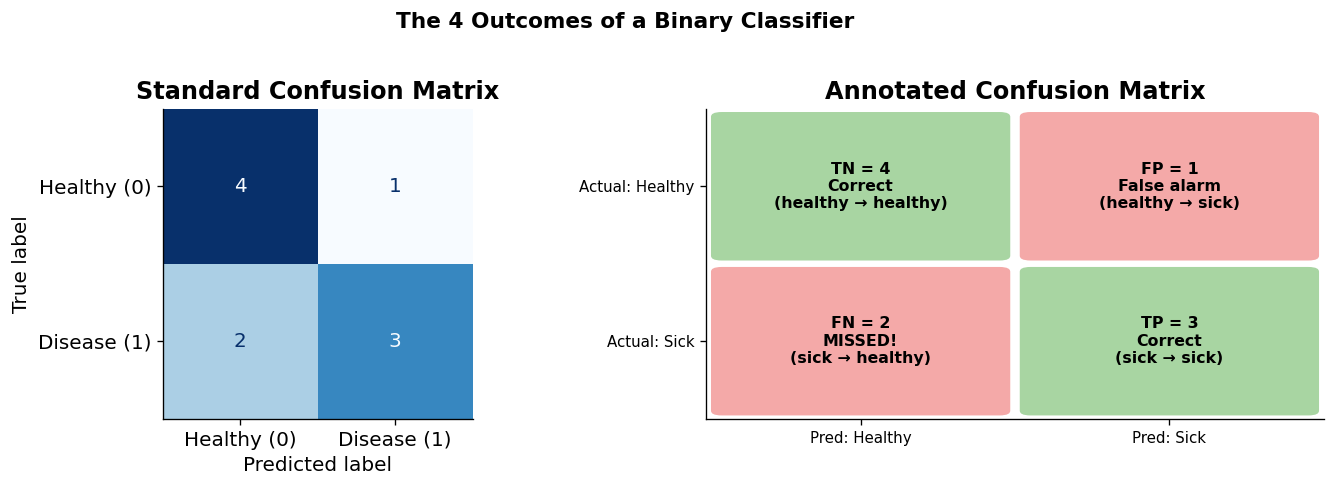

In [19]:
# ── Visualise both a standard and annotated confusion matrix ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: sklearn's built-in heatmap
ConfusionMatrixDisplay(cm, display_labels=['Healthy (0)', 'Disease (1)']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Standard Confusion Matrix', fontweight='bold')

# Right: colour-coded with TP/TN/FP/FN labels
cell_colors = [['#a8d5a2', '#f4a9a8'],
               ['#f4a9a8', '#a8d5a2']]
cell_text = [
    [f'TN = {TN}\nCorrect\n(healthy → healthy)', f'FP = {FP}\nFalse alarm\n(healthy → sick)'],
    [f'FN = {FN}\nMISSED!\n(sick → healthy)',    f'TP = {TP}\nCorrect\n(sick → sick)']
]
axes[1].set_xlim(0,2); axes[1].set_ylim(0,2)
for r in range(2):
    for c in range(2):
        rect = mpatches.FancyBboxPatch((c+0.05, r+0.05), 0.9, 0.9,
                                       boxstyle='round,pad=0.04',
                                       facecolor=cell_colors[1-r][c],
                                       edgecolor='white', linewidth=2)
        axes[1].add_patch(rect)
        axes[1].text(c+0.5, r+0.5, cell_text[1-r][c],
                     ha='center', va='center', fontsize=9.5, fontweight='bold')
axes[1].set_xticks([0.5,1.5])
axes[1].set_xticklabels(['Pred: Healthy','Pred: Sick'], fontsize=9)
axes[1].set_yticks([0.5,1.5])
axes[1].set_yticklabels(['Actual: Sick','Actual: Healthy'], fontsize=9)
axes[1].set_title('Annotated Confusion Matrix', fontweight='bold')

plt.suptitle('The 4 Outcomes of a Binary Classifier', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 2️⃣ Accuracy — The Most Intuitive (But Dangerous) Metric

$$\boxed{\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}}$$

### 🧠 Plain English
> *"Out of every single prediction the model made — correct ones AND wrong ones — what fraction was right?"*

### ✅ When it works well
When classes are **roughly balanced** (e.g. ~50% sick, ~50% healthy). Accuracy is easy to interpret and communicate.

### ⚠️ The Imbalance Trap (very common in real life!)
If 95 out of 100 patients are healthy, a model that **always predicts "healthy" — no learning at all** — scores **95% accuracy**. But it misses every single sick patient.

This is why in fields like fraud detection, cancer screening, or fault detection, accuracy alone is **never reported without other metrics**.

In [4]:
# ── Step-by-step accuracy calculation ────────────────────────────────────────
total = TP + TN + FP + FN
accuracy_manual = (TP + TN) / total

print("📐 Manual Calculation (step by step):")
print(f"   Total predictions = TP + TN + FP + FN = {TP}+{TN}+{FP}+{FN} = {total}")
print(f"   Correct = TP + TN = {TP} + {TN} = {TP+TN}")
print(f"   Accuracy = {TP+TN} / {total} = {accuracy_manual:.2f}  →  {accuracy_manual:.0%} correct")
print()
print(f"🔧 sklearn verify: {accuracy_score(y_true, y_pred):.2f}  ✅")

print("\n" + "─"*55)
print("⚠️  THE IMBALANCE TRAP DEMO")
print("─"*55)
y_true_imb  = np.array([0]*95 + [1]*5)
y_pred_lazy = np.array([0]*100)           # Always predict healthy

print(f"  Dataset: 95 healthy + 5 sick (95/5 split)")
print(f"  Lazy model: always predicts 'healthy' (zero learning!)")
print(f"  Accuracy  = {accuracy_score(y_true_imb, y_pred_lazy):.0%}  ← looks great!")
print(f"  Recall    = {recall_score(y_true_imb, y_pred_lazy, zero_division=0):.0%}  ← catches ZERO sick patients 😱")
print(f"\n  Lesson: A high accuracy score can hide a completely useless model!")

📐 Manual Calculation (step by step):
   Total predictions = TP + TN + FP + FN = 3+4+1+2 = 10
   Correct = TP + TN = 3 + 4 = 7
   Accuracy = 7 / 10 = 0.70  →  70% correct

🔧 sklearn verify: 0.70  ✅

───────────────────────────────────────────────────────
⚠️  THE IMBALANCE TRAP DEMO
───────────────────────────────────────────────────────
  Dataset: 95 healthy + 5 sick (95/5 split)
  Lazy model: always predicts 'healthy' (zero learning!)
  Accuracy  = 95%  ← looks great!
  Recall    = 0%  ← catches ZERO sick patients 😱

  Lesson: A high accuracy score can hide a completely useless model!


---
## 3️⃣ Precision — How Trustworthy Are Positive Predictions?

$$\boxed{\text{Precision} = \frac{TP}{TP + FP}}$$

### 🧠 Plain English
> *"When the model raises an alarm and says 'this person is sick', how often is it actually right?"*

Precision only examines **the subset of patients the model flagged as sick**. Within that group, what fraction were genuinely sick?

```
  All patients the model predicted as SICK:
  ┌──────────────────────────────────────────┐
  │  TP   │  TP   │  FP   │  TP   │  TP    │
  │ sick  │ sick  │healthy│ sick  │ sick   │
  │  ✅   │  ✅   │  ❌   │  ✅   │  ✅   │
  └──────────────────────────────────────────┘
   Precision = 4 correct out of 5 flagged = 0.80
```

### 🎯 High Precision matters when False Positives are expensive:
| Situation | Cost of a False Positive |
|-----------|-------------------------|
| Spam filter | A real email goes to spam → user loses info |
| Criminal justice AI | Innocent person accused |
| Product recall | Safe products recalled unnecessarily = millions in cost |
| Medical surgery | Unnecessary surgery with real health risk |

In [5]:
precision_manual = TP / (TP + FP)

print("📐 Manual Calculation:")
print(f"   Precision = TP / (TP + FP)")
print(f"            = {TP} / ({TP} + {FP})")
print(f"            = {TP} / {TP+FP}")
print(f"            = {precision_manual:.2f}")
print()
print(f"🔧 sklearn verify: {precision_score(y_true, y_pred):.2f}  ✅")
print()
print(f"📢 Interpretation:")
print(f"   The model flagged {TP+FP} patients as sick.")
print(f"   Of those, {TP} were genuinely sick — that's {precision_manual:.0%}.")
print(f"   {FP} were healthy but falsely alarmed. ← These are the false positives.")
print(f"\n   If precision is 0.75, the doctor can trust 75% of the model's 'sick' flags.")

📐 Manual Calculation:
   Precision = TP / (TP + FP)
            = 3 / (3 + 1)
            = 3 / 4
            = 0.75

🔧 sklearn verify: 0.75  ✅

📢 Interpretation:
   The model flagged 4 patients as sick.
   Of those, 3 were genuinely sick — that's 75%.
   1 were healthy but falsely alarmed. ← These are the false positives.

   If precision is 0.75, the doctor can trust 75% of the model's 'sick' flags.


---
## 4️⃣ Recall — How Many Sick People Did We Actually Find?

$$\boxed{\text{Recall} = \frac{TP}{TP + FN}}$$

Also known as: **Sensitivity** | **True Positive Rate (TPR)** | **Hit Rate**

### 🧠 Plain English
> *"Out of ALL the patients who are actually sick, how many did the model successfully catch?"*

Recall only examines the **actually sick population**. Of all those patients, what fraction did we correctly detect?

```
  ALL actually sick patients:
  ┌──────────────────────────────────────────────┐
  │  TP   │  TP   │  FN   │  TP   │  FN   │ FN │
  │caught │caught │missed │caught │missed │miss│
  │  ✅   │  ✅   │  ❌   │  ✅   │  ❌   │ ❌ │
  └──────────────────────────────────────────────┘
   Recall = 3 caught out of 6 actual = 0.50
```

### 🎯 High Recall matters when False Negatives are dangerous:
| Situation | Cost of a False Negative |
|-----------|-------------------------|
| Cancer screening | Missed diagnosis → delayed treatment → worse outcome |
| COVID / pandemic | Missed positive → community spread |
| Bank fraud | Missed fraud → financial loss |
| Safety systems | Missed fault → equipment failure or accident |

In [6]:
recall_manual = TP / (TP + FN)

print("📐 Manual Calculation:")
print(f"   Recall = TP / (TP + FN)")
print(f"         = {TP} / ({TP} + {FN})")
print(f"         = {TP} / {TP+FN}")
print(f"         = {recall_manual:.2f}")
print()
print(f"🔧 sklearn verify: {recall_score(y_true, y_pred):.2f}  ✅")
print()
print(f"📢 Interpretation:")
print(f"   There are {TP+FN} patients who are actually sick.")
print(f"   The model caught {TP} of them — {recall_manual:.0%} coverage.")
print(f"   It MISSED {FN} sick patient(s). ← These are the dangerous misses (FN).")

print()
print("─" * 55)
print("🔁 Precision vs Recall — Two different questions:")
print("─" * 55)
print(f"  Precision: Of {TP+FP} 'sick' flags    → {TP} real  ({precision_manual:.0%} quality/trust)")
print(f"  Recall:    Of {TP+FN} actual sick     → {TP} found ({recall_manual:.0%} coverage/reach)")

📐 Manual Calculation:
   Recall = TP / (TP + FN)
         = 3 / (3 + 2)
         = 3 / 5
         = 0.60

🔧 sklearn verify: 0.60  ✅

📢 Interpretation:
   There are 5 patients who are actually sick.
   The model caught 3 of them — 60% coverage.
   It MISSED 2 sick patient(s). ← These are the dangerous misses (FN).

───────────────────────────────────────────────────────
🔁 Precision vs Recall — Two different questions:
───────────────────────────────────────────────────────
  Precision: Of 4 'sick' flags    → 3 real  (75% quality/trust)
  Recall:    Of 5 actual sick     → 3 found (60% coverage/reach)


---
## ⚖️ The Precision–Recall Trade-off

Precision and Recall pull in **opposite directions** as you move the decision threshold.

Most classifiers output a **probability** (e.g. 0.73), not a hard label. You apply a **threshold** to decide:

```
  Probability = 0.73

  If threshold = 0.5  → 0.73 ≥ 0.5 → Predict SICK
  If threshold = 0.8  → 0.73 < 0.8 → Predict HEALTHY  ← more conservative
  If threshold = 0.3  → 0.73 ≥ 0.3 → Predict SICK     ← more aggressive
```

| Lower threshold | Higher threshold |
|----------------|------------------|
| Flags MORE people as sick | Flags FEWER people as sick |
| ↑ Recall (catches more real cases) | ↑ Precision (less false alarms) |
| ↓ Precision (more false alarms) | ↓ Recall (misses more real cases) |

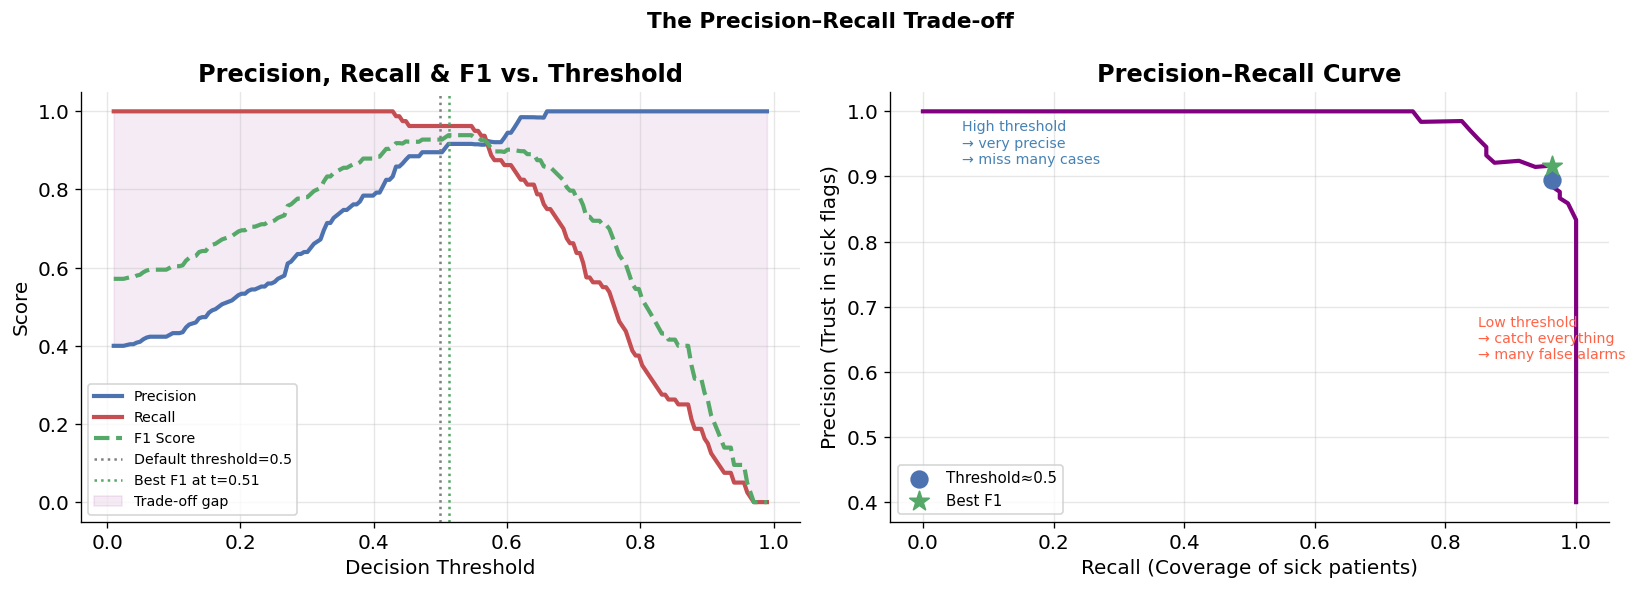

In [7]:
np.random.seed(42)
# Simulate: sick patients tend to have higher model probability scores
prob_sick    = np.random.beta(6, 2, 80)    # high probs for sick
prob_healthy = np.random.beta(2, 6, 120)   # low probs for healthy
prob_all  = np.concatenate([prob_sick, prob_healthy])
true_all  = np.concatenate([np.ones(80), np.zeros(120)])

thresholds = np.linspace(0.01, 0.99, 200)
precisions, recalls, f1s = [], [], []
for t in thresholds:
    preds = (prob_all >= t).astype(int)
    if preds.sum() == 0:
        precisions.append(1.0); recalls.append(0.0); f1s.append(0.0)
    else:
        p = precision_score(true_all, preds, zero_division=0)
        r = recall_score(true_all, preds)
        precisions.append(p); recalls.append(r)
        f1s.append(2*p*r/(p+r) if (p+r)>0 else 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: all three vs threshold
axes[0].plot(thresholds, precisions, label='Precision', color='#4C72B0', lw=2.5)
axes[0].plot(thresholds, recalls,   label='Recall',    color='#C44E52', lw=2.5)
axes[0].plot(thresholds, f1s,       label='F1 Score',  color='#55A868', lw=2.5, ls='--')
axes[0].axvline(0.5, color='gray', ls=':', lw=1.5, label='Default threshold=0.5')
best_t = thresholds[np.argmax(f1s)]
axes[0].axvline(best_t, color='#55A868', ls=':', lw=1.5, label=f'Best F1 at t={best_t:.2f}')
axes[0].fill_between(thresholds, precisions, recalls, alpha=0.08, color='purple',
                     label='Trade-off gap')
axes[0].set_xlabel('Decision Threshold'); axes[0].set_ylabel('Score')
axes[0].set_title('Precision, Recall & F1 vs. Threshold', fontweight='bold')
axes[0].legend(fontsize=8.5); axes[0].grid(alpha=0.3)

# Right: Precision-Recall curve
axes[1].plot(recalls, precisions, color='purple', lw=2.5)
axes[1].scatter([recalls[100]], [precisions[100]], s=100, color='#4C72B0',
                zorder=5, label='Threshold≈0.5')
axes[1].scatter([recalls[np.argmax(f1s)]], [precisions[np.argmax(f1s)]],
                s=150, color='#55A868', marker='*', zorder=5, label='Best F1')
axes[1].annotate('Low threshold\n→ catch everything\n→ many false alarms',
                 xy=(0.85, 0.62), fontsize=8.5, color='tomato')
axes[1].annotate('High threshold\n→ very precise\n→ miss many cases',
                 xy=(0.06, 0.92), fontsize=8.5, color='steelblue')
axes[1].set_xlabel('Recall (Coverage of sick patients)')
axes[1].set_ylabel('Precision (Trust in sick flags)')
axes[1].set_title('Precision–Recall Curve', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.suptitle('The Precision–Recall Trade-off', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5️⃣ F1 Score — One Number to Balance Both

$$\boxed{\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{2 \cdot TP}{2 \cdot TP + FP + FN}}$$

### 🧠 Plain English
> *"Give me a single score that captures both how trustworthy and how complete my positive predictions are."*

- F1 = **1.0** → perfect (both Precision and Recall are 1.0)  
- F1 = **0.0** → worst (either Precision or Recall is 0.0)  
- F1 is high **only when BOTH metrics are high simultaneously**

### ✅ When to use F1
- Dataset is **imbalanced** (so accuracy is misleading)
- **Both** false positives and false negatives carry real cost
- You need **one number** for model comparison

In [8]:
f1_manual = 2 * (precision_manual * recall_manual) / (precision_manual + recall_manual)

print("📐 Manual Calculation (using Precision & Recall):")
print(f"   F1 = 2 × (P × R) / (P + R)")
print(f"      = 2 × ({precision_manual:.3f} × {recall_manual:.3f}) / ({precision_manual:.3f} + {recall_manual:.3f})")
print(f"      = 2 × {precision_manual*recall_manual:.4f} / {precision_manual+recall_manual:.4f}")
print(f"      = {f1_manual:.3f}")
print()

f1_alt = (2*TP) / (2*TP + FP + FN)
print("📐 Alternative formula (directly from TP, FP, FN):")
print(f"   F1 = 2·TP / (2·TP + FP + FN)")
print(f"      = 2×{TP} / (2×{TP} + {FP} + {FN})")
print(f"      = {2*TP} / {2*TP+FP+FN}")
print(f"      = {f1_alt:.3f}  ← same result ✅")
print()
print(f"🔧 sklearn verify: {f1_score(y_true, y_pred):.3f}  ✅")

📐 Manual Calculation (using Precision & Recall):
   F1 = 2 × (P × R) / (P + R)
      = 2 × (0.750 × 0.600) / (0.750 + 0.600)
      = 2 × 0.4500 / 1.3500
      = 0.667

📐 Alternative formula (directly from TP, FP, FN):
   F1 = 2·TP / (2·TP + FP + FN)
      = 2×3 / (2×3 + 1 + 2)
      = 6 / 9
      = 0.667  ← same result ✅

🔧 sklearn verify: 0.667  ✅


---
## 6️⃣ 🔬 Deep Dive: WHY Harmonic Mean, NOT Arithmetic Mean?

This is the most frequently asked question when students first encounter F1. Let's settle it thoroughly.

---

### Step 1 — What is an Arithmetic Mean?

$$\text{Arithmetic Mean} = \frac{P + R}{2}$$

The **simple average**. Adds both values and divides by 2. Everyone learns this in school.

---

### Step 2 — What is a Harmonic Mean?

$$\text{Harmonic Mean} = \frac{2}{\dfrac{1}{P} + \dfrac{1}{R}} = \frac{2PR}{P+R}$$

The harmonic mean is the **reciprocal of the arithmetic mean of the reciprocals**.

In plain terms: flip the numbers, average them, then flip back.

---

### Step 3 — The Key Difference

The harmonic mean **gravitates toward the smaller value** and **punishes extreme imbalance**:

| Precision | Recall | Arithmetic (P+R)/2 | Harmonic (F1) | Verdict |
|-----------|--------|-------------------|---------------|---------|
| 0.9 | 0.9 | 0.90 | **0.90** | Same (no imbalance) |
| 0.9 | 0.5 | 0.70 | **0.643** | Harmonic is lower |
| 0.9 | 0.1 | 0.50 | **0.18** | Big gap! |
| 1.0 | 0.0 | 0.50 | **0.00** | F1 is zero — correct! |

> ⚡ Critical: If either P or R is 0, **F1 = 0 always** — but arithmetic mean would give **0.5** when the other is 1.0. That's dangerously misleading.

---

### Step 4 — The Mathematical Reason

When R is very small, 1/R becomes **enormous**:
$$\text{HM} = \frac{2}{1/P + 1/R} \approx \frac{2}{1/R} = 2R \cdot \frac{P}{P} \approx R \quad \text{(when R → 0)}$$

So the harmonic mean **gets pulled down toward the minimum** of the two values, not their average.

---

### Step 5 — Why This is Exactly What We Want

Imagine two models:
- **Model A**: Precision = 0.95, Recall = 0.05 → Nearly useless (catches 5% of sick people)
- **Model B**: Precision = 0.50, Recall = 0.50 → Reasonably useful in both dimensions

**Arithmetic mean gives both = 0.50** → Can't distinguish them!  
**Harmonic mean: A = 0.095, B = 0.50** → Correctly reveals A is terrible!

In [9]:
# ╔══════════════════════════════════════════════════════╗
# ║  CELL — Arithmetic vs Harmonic: Full Comparison     ║
# ╚══════════════════════════════════════════════════════╝

print("=" * 72)
print("  HARMONIC MEAN (F1) vs ARITHMETIC MEAN — Complete Comparison")
print("=" * 72)

cases = [
    ('Both perfect',              1.00, 1.00),
    ('Both high & balanced',      0.90, 0.90),
    ('Moderately unbalanced',     0.90, 0.50),
    ('Highly unbalanced',         0.90, 0.10),
    ('Extremely unbalanced',      0.90, 0.01),
    ('One is exactly zero',       0.90, 0.00),
    ('Both moderate & balanced',  0.60, 0.60),
    ('Both low',                  0.20, 0.20),
    ('Completely wrong',          0.00, 0.00),
]

print(f"\n{'Scenario':<30} {'P':>5} {'R':>5} {'Arith.(P+R)/2':>14} {'Harmonic F1':>13} {'Penalty':>9} {'Alert':>20}")
print("-" * 100)
for name, p, r in cases:
    arith = (p + r) / 2
    harm  = (2*p*r/(p+r)) if (p+r) > 0 else 0.0
    penalty = arith - harm
    alert = '⚠️ MISLEADING ARITH!' if penalty > 0.2 else ('← same' if penalty < 0.005 else '')
    print(f"{name:<30} {p:>5.2f} {r:>5.2f} {arith:>14.3f} {harm:>13.3f} {penalty:>9.3f} {alert:>20}")

print()
print("Key takeaways:")
print("  1. When P ≈ R  → Harmonic ≈ Arithmetic (penalty ≈ 0)")
print("  2. When P ≠ R  → Harmonic << Arithmetic (large penalty)")
print("  3. When either = 0 → Harmonic = 0 always (arithmetic would give > 0 — wrong!)")

  HARMONIC MEAN (F1) vs ARITHMETIC MEAN — Complete Comparison

Scenario                           P     R  Arith.(P+R)/2   Harmonic F1   Penalty                Alert
----------------------------------------------------------------------------------------------------
Both perfect                    1.00  1.00          1.000         1.000     0.000               ← same
Both high & balanced            0.90  0.90          0.900         0.900     0.000               ← same
Moderately unbalanced           0.90  0.50          0.700         0.643     0.057                     
Highly unbalanced               0.90  0.10          0.500         0.180     0.320 ⚠️ MISLEADING ARITH!
Extremely unbalanced            0.90  0.01          0.455         0.020     0.435 ⚠️ MISLEADING ARITH!
One is exactly zero             0.90  0.00          0.450         0.000     0.450 ⚠️ MISLEADING ARITH!
Both moderate & balanced        0.60  0.60          0.600         0.600     0.000               ← same
Both low    

In [ ]:
# ╔══════════════════════════════════════════════════════╗
# ║  CELL — The Cheating Model Experiment               ║
# ╚══════════════════════════════════════════════════════╝

print("🎭 THE CHEATING MODEL EXPERIMENT")
print("=" * 60)
print()
print("Four models, all with the SAME arithmetic mean = 0.50.")
print("Which ones are actually good?")
print()

models = [
    ('Model A: high P, tiny R',   0.95, 0.05),
    ('Model B: balanced',         0.50, 0.50),
    ('Model C: balanced, better', 0.80, 0.80),
    ('Model D: perfect P, zero R',1.00, 0.00),
]

print(f"{'Model':<30} {'P':>5} {'R':>5} {'Arith.':>10} {'F1 (Harm.)':>12} {'Good?':>8}")
print("-" * 75)
for name, p, r in models:
    arith = (p + r) / 2
    harm  = (2*p*r/(p+r)) if (p+r) > 0 else 0.0
    good = '✅ Yes' if harm >= 0.5 else '❌ No'
    print(f"{name:<30} {p:>5.2f} {r:>5.2f} {arith:>10.3f} {harm:>12.3f} {good:>8}")

print()
print("🔑 Models A and D both have Arithmetic Mean = 0.50")
print("   but F1 = 0.095 and 0.000 → they are TERRIBLE models.")
print()
print("   If we used arithmetic mean as our metric, we'd mistakenly")
print("   think Model A is as good as Model B. The harmonic mean")
print("   correctly exposes the imbalance.")
print()
print("✅ The rule: To score well on F1, you MUST perform well on")
print("   BOTH precision AND recall — no free rides!")

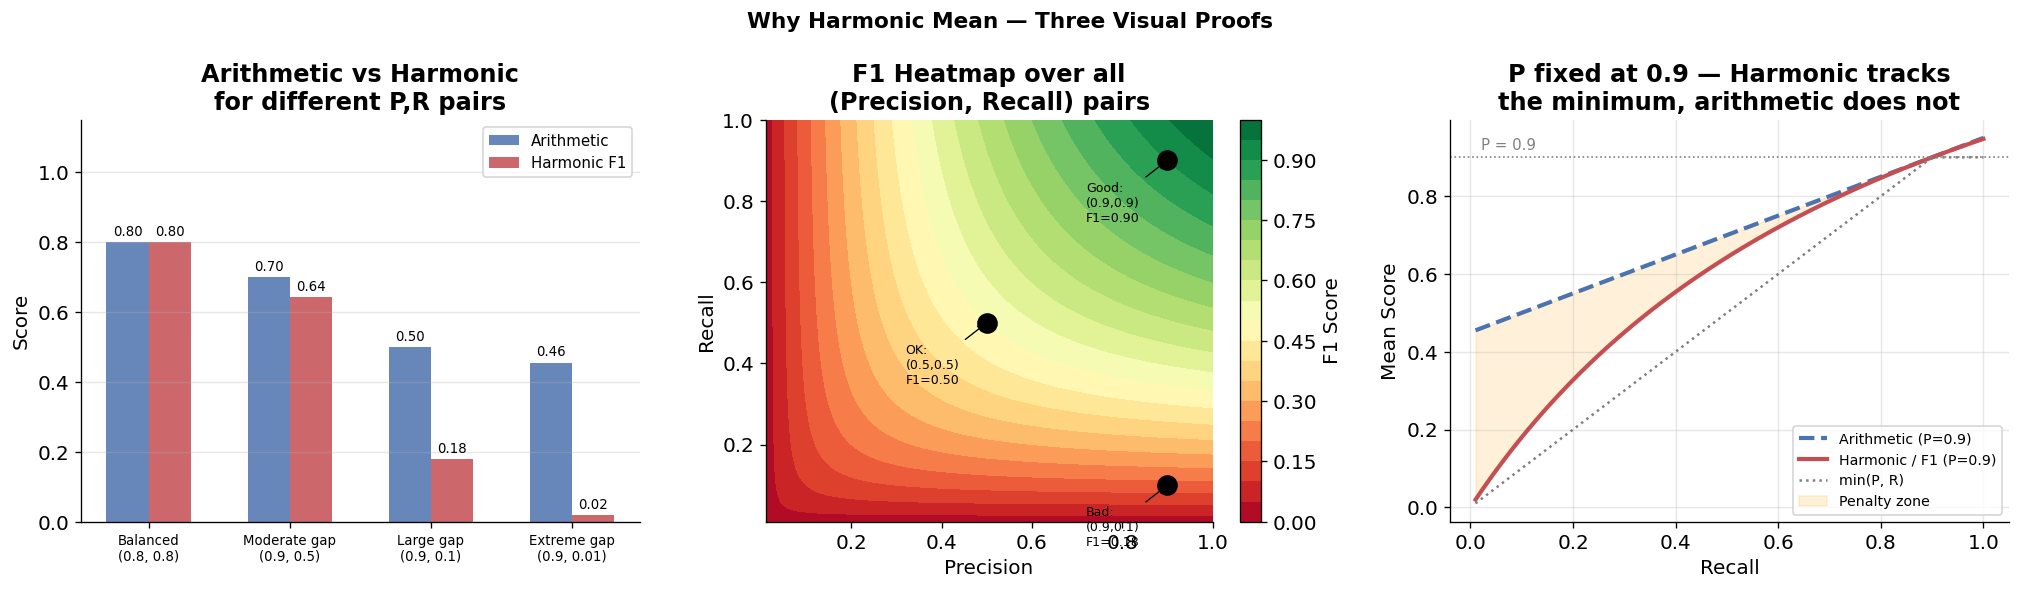

In [18]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL — Visual: Why Harmonic Pulls Toward the Minimum  ║
# ╚══════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Panel 1: Side-by-side bar for specific model pairs ───────────────────────
model_labels = [
    'Balanced\n(0.8, 0.8)',
    'Moderate gap\n(0.9, 0.5)',
    'Large gap\n(0.9, 0.1)',
    'Extreme gap\n(0.9, 0.01)'
]
ps = [0.8, 0.9, 0.9, 0.9]
rs = [0.8, 0.5, 0.1, 0.01]
ariths = [(p+r)/2 for p,r in zip(ps,rs)]
harms  = [2*p*r/(p+r) for p,r in zip(ps,rs)]

x = np.arange(4); w = 0.3
b1 = axes[0].bar(x-w/2, ariths, w, label='Arithmetic', color='#4C72B0', alpha=0.85)
b2 = axes[0].bar(x+w/2, harms,  w, label='Harmonic F1', color='#C44E52', alpha=0.85)
for bar in list(b1)+list(b2):
    v = bar.get_height()
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.2f}',
                 ha='center', va='bottom', fontsize=8)
axes[0].set_xticks(x); axes[0].set_xticklabels(model_labels, fontsize=8)
axes[0].set_ylim(0, 1.15); axes[0].set_ylabel('Score')
axes[0].set_title('Arithmetic vs Harmonic\nfor different P,R pairs', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)

# ── Panel 2: F1 heatmap over all P,R combinations ────────────────────────────
p_g = np.linspace(0.01, 1, 150)
r_g = np.linspace(0.01, 1, 150)
PG, RG = np.meshgrid(p_g, r_g)
F1_g = 2*PG*RG/(PG+RG)

im = axes[1].contourf(p_g, r_g, F1_g, levels=20, cmap='RdYlGn')
plt.colorbar(im, ax=axes[1], label='F1 Score')
axes[1].set_xlabel('Precision'); axes[1].set_ylabel('Recall')
axes[1].set_title('F1 Heatmap over all\n(Precision, Recall) pairs', fontweight='bold')

for p, r, lbl in [(0.9,0.1,'Bad:\n(0.9,0.1)\nF1=0.18'), (0.5,0.5,'OK:\n(0.5,0.5)\nF1=0.50'), (0.9,0.9,'Good:\n(0.9,0.9)\nF1=0.90')]:
    f1 = 2*p*r/(p+r)
    axes[1].scatter(p, r, s=130, color='black', zorder=5)
    axes[1].annotate(lbl, xy=(p, r), xytext=(p-0.18, r-0.15),
                     fontsize=7.5, arrowprops=dict(arrowstyle='->', color='black', lw=0.8))

# ── Panel 3: Fixed P=0.9, vary R — show how HM tracks min ───────────────────
r_range = np.linspace(0.01, 1, 300)
P_fixed = 0.9
arith_curve = (P_fixed + r_range) / 2
harm_curve  = 2 * P_fixed * r_range / (P_fixed + r_range)
min_curve   = np.minimum(P_fixed, r_range)   # the floor

axes[2].plot(r_range, arith_curve, label=f'Arithmetic (P={P_fixed})',
             color='#4C72B0', lw=2.5, ls='--')
axes[2].plot(r_range, harm_curve,  label=f'Harmonic / F1 (P={P_fixed})',
             color='#C44E52', lw=2.5)
axes[2].plot(r_range, min_curve,   label='min(P, R)',
             color='gray', lw=1.5, ls=':')
axes[2].fill_between(r_range, harm_curve, arith_curve, alpha=0.15,
                     color='orange', label='Penalty zone')
axes[2].axhline(P_fixed, color='gray', ls=':', lw=1)
axes[2].text(0.02, P_fixed+0.02, f'P = {P_fixed}', fontsize=9, color='gray')

axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Mean Score')
axes[2].set_title(f'P fixed at {P_fixed} — Harmonic tracks\nthe minimum, arithmetic does not',
                  fontweight='bold')
axes[2].legend(fontsize=8.5); axes[2].grid(alpha=0.3)

plt.suptitle('Why Harmonic Mean — Three Visual Proofs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL — Mathematical Step-Through with Numbers         ║
# ╚══════════════════════════════════════════════════════════╝

print("📐 MATHEMATICAL STEP-THROUGH — Why HM Tracks the Minimum")
print("=" * 62)
print()
print("Recall: HM = 2 / (1/P + 1/R)")
print("             ↑ reciprocal of the average of (1/P) and (1/R)")
print()

examples = [(0.9, 0.9), (0.9, 0.5), (0.9, 0.1), (0.9, 0.01)]
print(f"{'(P, R)':<15} {'1/P':>7} {'1/R':>9} {'avg(1/P,1/R)':>14} {'F1=2/avg':>10} {'min(P,R)':>10}")
print("-" * 70)
for p, r in examples:
    inv_avg = (1/p + 1/r) / 2
    hm = 2 / (1/p + 1/r)    # = 1 / inv_avg
    print(f"({p}, {r:<4})     {1/p:>7.2f} {1/r:>9.2f} {inv_avg:>14.3f} {hm:>10.3f} {min(p,r):>10.2f}")

print()
print("Observation: When R becomes tiny (e.g. 0.01):")
print("  1/R becomes HUGE (= 100)")
print("  The average of (1/P, 1/R) is dominated by 1/R")
print("  So HM = 2/(1/P + 1/R) ≈ 2/(1/R) = 2R × P/(P+0) ≈ R")
print()
print("  → The harmonic mean is approximately equal to the SMALLER value.")
print("  → That's why it punishes imbalance so strongly!")
print()
print("One-sentence rule:")
print("  Harmonic mean asks: 'How good is your WEAKEST metric?'")
print("  Arithmetic mean asks: 'What is your average metric?'")
print()
print("For F1, we want the HARMONIC answer — a model must be")
print("good at BOTH precision AND recall, not just one.")

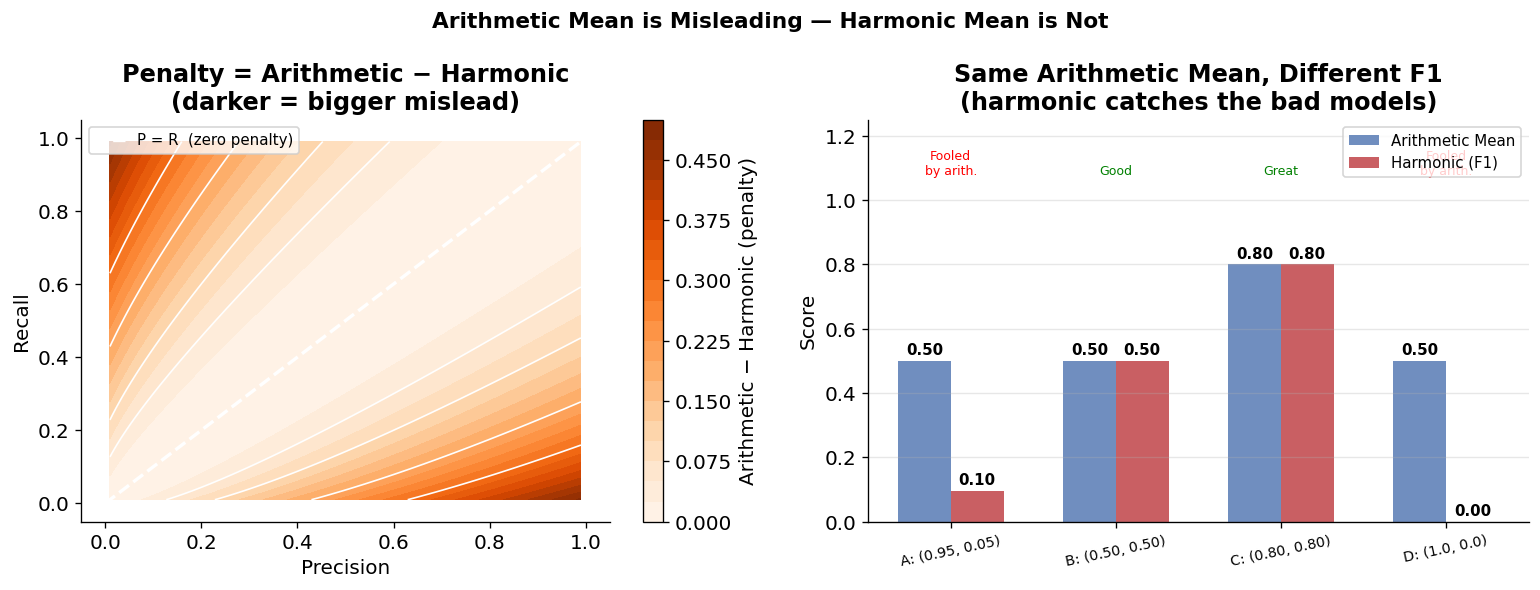

In [22]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL — Penalty Map: Where Arithmetic Mean Misleads    ║
# ╚══════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

p_g = np.linspace(0.01, 0.99, 200)
r_g = np.linspace(0.01, 0.99, 200)
PG, RG = np.meshgrid(p_g, r_g)
AM = (PG + RG) / 2
HM = 2*PG*RG / (PG+RG)
DIFF = AM - HM   # always ≥ 0

# Left: penalty heatmap
ct = axes[0].contourf(p_g, r_g, DIFF, levels=20, cmap='Oranges')
plt.colorbar(ct, ax=axes[0], label='Arithmetic − Harmonic (penalty)')
axes[0].contour(p_g, r_g, DIFF, levels=[0.05,0.1,0.2,0.3], colors='white', linewidths=1)
axes[0].plot([0,1],[0,1], 'w--', lw=2, label='P = R  (zero penalty)')
axes[0].set_xlabel('Precision'); axes[0].set_ylabel('Recall')
axes[0].set_title('Penalty = Arithmetic − Harmonic\n(darker = bigger mislead)', fontweight='bold')
axes[0].legend(fontsize=9)

# Right: the four models comparison
model_names  = ['A: (0.95, 0.05)', 'B: (0.50, 0.50)', 'C: (0.80, 0.80)', 'D: (1.0, 0.0)']
p_vals = [0.95, 0.50, 0.80, 1.00]
r_vals = [0.05, 0.50, 0.80, 0.00]
am_vals = [(p+r)/2 for p,r in zip(p_vals,r_vals)]
hm_vals = [2*p*r/(p+r) if (p+r)>0 else 0 for p,r in zip(p_vals,r_vals)]

x = np.arange(4); w = 0.32
ba = axes[1].bar(x-w/2, am_vals, w, label='Arithmetic Mean', color='#4C72B0', alpha=0.8)
bh = axes[1].bar(x+w/2, hm_vals, w, label='Harmonic (F1)',   color='#C44E52', alpha=0.9)
for bar, v in zip(list(ba)+list(bh), am_vals+hm_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.2f}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

# Annotations
for i, label in enumerate(['Fooled\nby arith.', 'Good', 'Great', 'Fooled\nby arith.']):
    col = 'red' if ' ' in label else 'green'
    axes[1].text(i, 1.08, label, ha='center', fontsize=7.5, color=col)

axes[1].set_xticks(x); axes[1].set_xticklabels(model_names, fontsize=8.5, rotation=12)
axes[1].set_ylim(0, 1.25); axes[1].set_ylabel('Score')
axes[1].set_title('Same Arithmetic Mean, Different F1\n(harmonic catches the bad models)', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Arithmetic Mean is Misleading — Harmonic Mean is Not', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
### 📋 Summary: Arithmetic vs Harmonic Mean

| Property | Arithmetic (P+R)/2 | Harmonic F1 |
|----------|-------------------|-------------|
| Formula | Simple average | Reciprocal of avg of reciprocals |
| Sensitive to low values? | ❌ No — high value compensates | ✅ Yes — pulled toward minimum |
| If P=1.0, R=0.0 | Gives **0.50** (wrong!) | Gives **0.00** (correct) |
| Can be "gamed"? | ✅ Yes | ❌ No — must balance both |
| Standard in ML? | ❌ Not used | ✅ Yes |

### 💬 One-Sentence Answer to the Exam Question:
> **The harmonic mean is used because it is dominated by the smaller value — a model that is great at Precision but terrible at Recall (or vice versa) scores near zero, which correctly reflects that it is a bad model. Arithmetic mean would give it a misleadingly high score.**

---
## 7️⃣ Specificity — The Forgotten Partner of Recall

$$\boxed{\text{Specificity} = \frac{TN}{TN + FP}}$$

Also known as: **True Negative Rate (TNR)** | **Selectivity**

### 🧠 Plain English
> *"Out of ALL patients who are actually healthy, how many did the model correctly identify as healthy?"*

### 🔁 Recall and Specificity are mirror images:

```
  RECALL       = TP / (TP + FN)   ← focuses on the POSITIVE class (sick patients)
  SPECIFICITY  = TN / (TN + FP)   ← focuses on the NEGATIVE class (healthy patients)
```

| Metric | Looks at | Penalises |
|--------|----------|----------|
| Recall | Actual Positives | Missing sick patients (FN) |
| Specificity | Actual Negatives | False-alarming healthy patients (FP) |

### 🎯 Why it matters:
A blood test with **low specificity** sends many healthy people for unnecessary follow-up procedures — causing anxiety, cost, and sometimes harm.  
Together, Recall + Specificity form the axes of the **ROC curve**, which is the gold standard for evaluating classifiers.

In [12]:
specificity_manual = TN / (TN + FP)

print("📐 Manual Calculation:")
print(f"   Specificity = TN / (TN + FP)")
print(f"              = {TN} / ({TN} + {FP})")
print(f"              = {TN} / {TN+FP}")
print(f"              = {specificity_manual:.2f}")
print()
print("⚠️  sklearn has NO direct function for specificity.")
print("   Always extract TN and FP from the confusion matrix manually!")
print()
print("📢 Interpretation:")
print(f"   There are {TN+FP} actually healthy patients.")
print(f"   The model correctly said 'healthy' for {TN} of them ({specificity_manual:.0%}).")
print(f"   It wrongly flagged {FP} healthy patient(s) as sick. (False Positives)")
print()
print("─" * 55)
print("🔁 Recall vs Specificity — side-by-side:")
print("─" * 55)
print(f"   Recall      = {recall_manual:.2f}  → covers the SICK   group: {TP}/{TP+FN} caught")
print(f"   Specificity = {specificity_manual:.2f}  → covers the HEALTHY group: {TN}/{TN+FP} correctly cleared")

📐 Manual Calculation:
   Specificity = TN / (TN + FP)
              = 4 / (4 + 1)
              = 4 / 5
              = 0.80

⚠️  sklearn has NO direct function for specificity.
   Always extract TN and FP from the confusion matrix manually!

📢 Interpretation:
   There are 5 actually healthy patients.
   The model correctly said 'healthy' for 4 of them (80%).
   It wrongly flagged 1 healthy patient(s) as sick. (False Positives)

───────────────────────────────────────────────────────
🔁 Recall vs Specificity — side-by-side:
───────────────────────────────────────────────────────
   Recall      = 0.60  → covers the SICK   group: 3/5 caught
   Specificity = 0.80  → covers the HEALTHY group: 4/5 correctly cleared


---
## 8️⃣ All 5 Metrics Together — Complete Dashboard

In [13]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Metric':       ['Accuracy','Precision','Recall','F1 Score','Specificity'],
    'Formula':      ['(TP+TN)/N','TP/(TP+FP)','TP/(TP+FN)','2PR/(P+R)','TN/(TN+FP)'],
    'Value':        [round(accuracy_manual,3), round(precision_manual,3),
                     round(recall_manual,3), round(f1_manual,3), round(specificity_manual,3)],
    'Question answered': [
        'Overall, how often is the model correct?',
        'When it flags Positive, how often right?',
        'Of all true Positives, how many found?',
        'Balanced score for P and R?',
        'Of all true Negatives, how many cleared?'
    ],
    'Primary use': [
        'Balanced classes',
        'FP cost is high',
        'FN cost is high',
        'Both FP & FN matter + imbalanced data',
        'FP cost + negatives matter'
    ]
})
summary.set_index('Metric', inplace=True)
summary

,Formula,Value,Question answered,Primary use
Metric,,,,
Accuracy,(TP+TN)/N,0.700,"Overall, how often is the model correct?",Balanced classes
Precision,TP/(TP+FP),0.750,"When it flags Positive, how often right?",FP cost is high
Recall,TP/(TP+FN),0.600,"Of all true Positives, how many found?",FN cost is high
F1 Score,2PR/(P+R),0.667,Balanced score for P and R?,Both FP & FN matter + imbalanced data
Specificity,TN/(TN+FP),0.800,"Of all true Negatives, how many cleared?",FP cost + negatives matter


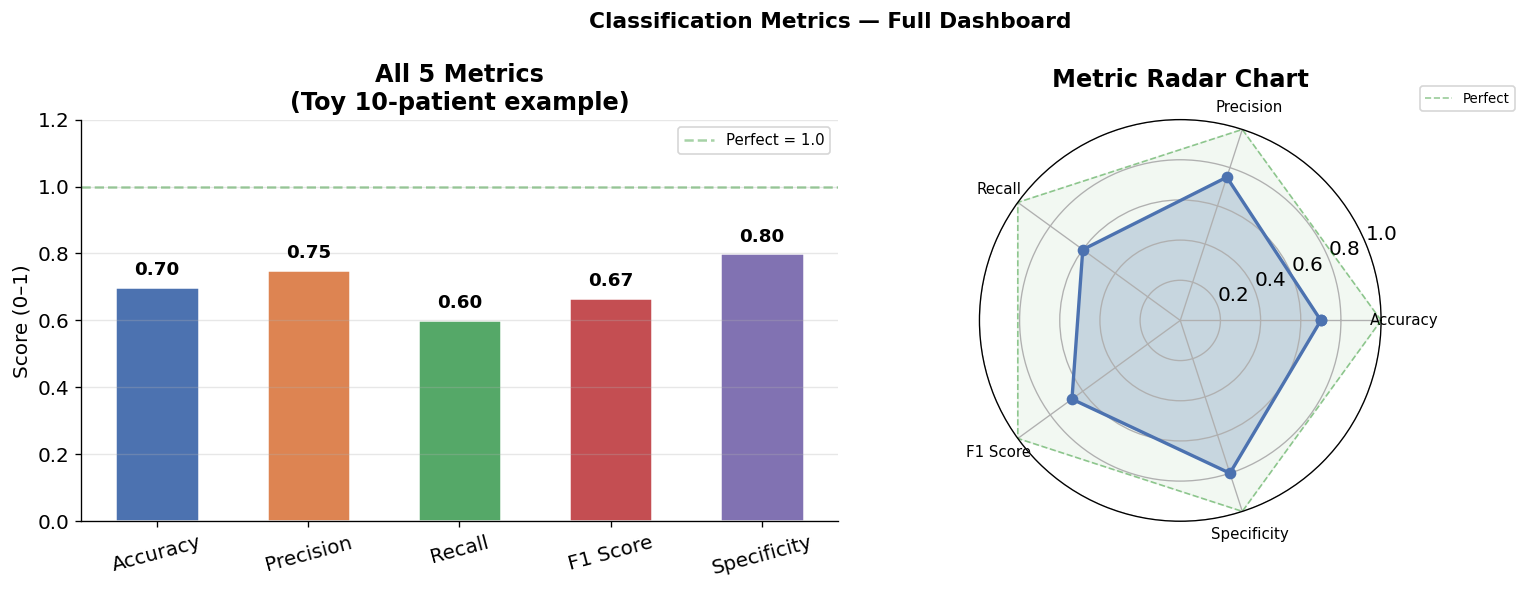

In [14]:
# ── Visual dashboard: bar + radar ─────────────────────────────────────────────
names  = ['Accuracy','Precision','Recall','F1 Score','Specificity']
values = [accuracy_manual, precision_manual, recall_manual, f1_manual, specificity_manual]

fig = plt.figure(figsize=(14, 5))
ax_bar = fig.add_subplot(121)
ax_rad = fig.add_subplot(122, polar=True)

# Bar chart
bars = ax_bar.bar(names, values, color=PALETTE, edgecolor='white', lw=1.5, width=0.55)
for bar, val in zip(bars, values):
    ax_bar.text(bar.get_x()+bar.get_width()/2, val+0.025,
                f'{val:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax_bar.set_ylim(0, 1.2); ax_bar.set_ylabel('Score (0–1)')
ax_bar.axhline(1.0, color='green', ls='--', alpha=0.35, label='Perfect = 1.0')
ax_bar.set_title('All 5 Metrics\n(Toy 10-patient example)', fontweight='bold')
ax_bar.legend(fontsize=9); ax_bar.grid(axis='y', alpha=0.3)
ax_bar.tick_params(axis='x', rotation=15)

# Radar chart
angles = np.linspace(0, 2*np.pi, len(names), endpoint=False).tolist()
v_loop = values + [values[0]]
a_loop = angles + [angles[0]]

ax_rad.plot(a_loop, v_loop, 'o-', color='#4C72B0', lw=2)
ax_rad.fill(a_loop, v_loop, alpha=0.25, color='#4C72B0')
perfect = [1.0]*(len(names)+1)
ax_rad.plot(a_loop, perfect, '--', color='green', lw=1, alpha=0.4, label='Perfect')
ax_rad.fill(a_loop, perfect, alpha=0.05, color='green')
ax_rad.set_xticks(angles)
ax_rad.set_xticklabels(names, fontsize=9)
ax_rad.set_ylim(0, 1)
ax_rad.set_title('Metric Radar Chart', fontweight='bold', pad=20)
ax_rad.legend(loc='upper right', fontsize=8, bbox_to_anchor=(1.35, 1.1))

plt.suptitle('Classification Metrics — Full Dashboard', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9️⃣ Real Model Demo — Logistic Regression on Imbalanced Data

Now let's apply everything to a **real trained model** on 1,000 synthetic patients (70% healthy, 30% sick).

In [15]:
# ── Generate dataset, train model, evaluate ───────────────────────────────────
X, y = make_classification(
    n_samples=1000, n_features=10, n_informative=5,
    weights=[0.7, 0.3],   # 70% healthy, 30% sick
    random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_pred_real = model.predict(X_test)

cm_real = confusion_matrix(y_test, y_pred_real)
TN_r, FP_r, FN_r, TP_r = cm_real.ravel()
spec_real = TN_r / (TN_r + FP_r)

print("── sklearn classification_report ──────────────────────────────")
print(classification_report(y_test, y_pred_real, target_names=['Healthy (0)','Disease (1)']))
print(f"Specificity (manual): {spec_real:.3f}")
print(f"Confusion matrix: TP={TP_r}  TN={TN_r}  FP={FP_r}  FN={FN_r}")
print()
print("📢 Key takeaway:")
print(f"   Model caught {TP_r}/{TP_r+FN_r} sick patients (Recall = {recall_score(y_test,y_pred_real):.0%})")
print(f"   Missed {FN_r} sick patients — these are the dangerous false negatives")
print(f"   Of {TP_r+FP_r} 'disease' flags, {TP_r} were correct (Precision = {precision_score(y_test,y_pred_real):.0%})")
print(f"   F1 = {f1_score(y_test,y_pred_real):.3f} balances the above trade-off")

── sklearn classification_report ──────────────────────────────
              precision    recall  f1-score   support

 Healthy (0)       0.78      0.95      0.85       193
 Disease (1)       0.84      0.50      0.63       107

    accuracy                           0.79       300
   macro avg       0.81      0.73      0.74       300
weighted avg       0.80      0.79      0.77       300

Specificity (manual): 0.948
Confusion matrix: TP=54  TN=183  FP=10  FN=53

📢 Key takeaway:
   Model caught 54/107 sick patients (Recall = 50%)
   Missed 53 sick patients — these are the dangerous false negatives
   Of 64 'disease' flags, 54 were correct (Precision = 84%)
   F1 = 0.632 balances the above trade-off


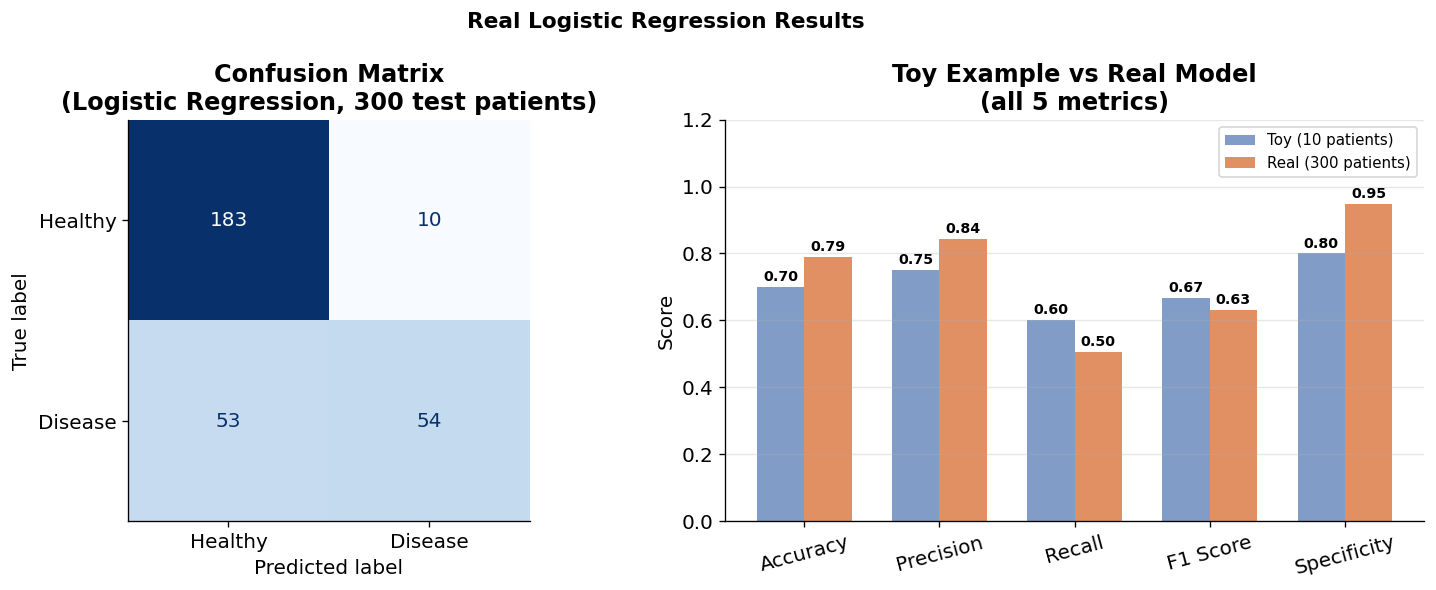

In [16]:
real_vals = [
    accuracy_score(y_test, y_pred_real),
    precision_score(y_test, y_pred_real),
    recall_score(y_test, y_pred_real),
    f1_score(y_test, y_pred_real),
    spec_real
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
ConfusionMatrixDisplay(cm_real, display_labels=['Healthy','Disease']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix\n(Logistic Regression, 300 test patients)', fontweight='bold')

# Grouped bars: toy vs real
x = np.arange(len(names)); w = 0.35
b1 = axes[1].bar(x-w/2, values,    w, label='Toy (10 patients)',  color='#4C72B0', alpha=0.7)
b2 = axes[1].bar(x+w/2, real_vals, w, label='Real (300 patients)', color='#DD8452', alpha=0.9)
for bar, v in zip(list(b1)+list(b2), values+real_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.2f}',
                 ha='center', va='bottom', fontsize=8.5, fontweight='bold')
axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=15)
axes[1].set_ylim(0, 1.2); axes[1].set_ylabel('Score')
axes[1].set_title('Toy Example vs Real Model\n(all 5 metrics)', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Real Logistic Regression Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔟 Decision Guide — Which Metric Should You Use?

```
START HERE
    │
    ▼
Are your classes balanced? (roughly 50/50)
    │
    ├── YES → Accuracy is a reasonable starting point
    │         (still report P, R, F1 for full picture)
    │
    └── NO  → Accuracy ALONE is MISLEADING
                   │
                   ├── Is missing a positive case dangerous?
                   │   (cancer, fraud, earthquake prediction)
                   │       └── Maximise RECALL  ← catch every sick person
                   │
                   ├── Is a false alarm expensive or harmful?
                   │   (spam filter, legal AI, unnecessary surgery)
                   │       └── Maximise PRECISION  ← only flag when sure
                   │
                   ├── Both FP and FN carry real cost?
                   │       └── Optimise F1 SCORE  ← harmonic balance of both
                   │
                   └── Also care about correctly clearing the negative class?
                           └── Report SPECIFICITY alongside Recall
```

---
## 📋 Quick Reference Cheat Sheet

| Metric | Formula | Penalises | Use when |
|--------|---------|-----------|----------|
| **Accuracy** | (TP+TN)/N | Wrong predictions | Balanced classes |
| **Precision** | TP/(TP+FP) | False Positives | False alarms are costly |
| **Recall** | TP/(TP+FN) | False Negatives | Missing cases is dangerous |
| **F1 Score** | 2PR/(P+R) | Imbalance between P & R | Imbalanced data + both errors matter |
| **Specificity** | TN/(TN+FP) | False Positives in negatives | Need to protect the negative class |

### Why Harmonic Mean for F1?
| Scenario | Arithmetic (P+R)/2 | Harmonic F1 |
|----------|-------------------|-------------|
| P=0.9, R=0.9 | 0.90 | 0.90 (same — balanced) |
| P=0.9, R=0.1 | **0.50** (misleading!) | **0.18** (honest!) |
| P=1.0, R=0.0 | **0.50** (misleading!) | **0.00** (honest!) |
| Rule | Can be gamed | **MUST balance both** |

In [23]:
# ╔══════════════════════════════════════════════════╗
# ║   🎓 STUDENT EXERCISE — with hidden answers     ║
# ╚══════════════════════════════════════════════════╝

print("🎓 STUDENT EXERCISE")
print("=" * 58)
print()
print("A disease screening model produces the following results:")
print()

y_ex_true = np.array([1, 1, 1, 1, 1, 1,   0, 0, 0, 0, 0, 0, 0, 0, 0])
y_ex_pred = np.array([1, 1, 0, 1, 0, 0,   1, 0, 0, 1, 0, 0, 0, 1, 0])

print(f"  y_true (reality) : {y_ex_true}")
print(f"  y_pred (model)   : {y_ex_pred}")
print()
print("📝 Tasks:")
print("  1. Draw the confusion matrix by hand (TP, TN, FP, FN counts)")
print("  2. Compute Accuracy, Precision, Recall, F1, Specificity manually")
print("  3. Compare Arithmetic Mean of (P, R) vs F1.")
print("     Why are they different? Which is better to use?")
print("  4. Verify all answers with sklearn")
print()
print("💡 Hints:")
print("  - Count 1s in y_true → total actual positives")
print("  - Count 0s in y_true → total actual negatives")
print("  - A TP is where y_true=1 AND y_pred=1")
print()
print("Uncomment the ANSWERS block below when ready to check.")

# ── ANSWERS — uncomment to reveal ────────────────────────────────────────────
cm_ex = confusion_matrix(y_ex_true, y_ex_pred)
TN_e, FP_e, FN_e, TP_e = cm_ex.ravel()
P_e = TP_e / (TP_e + FP_e)
R_e = TP_e / (TP_e + FN_e)
F1_e = 2*P_e*R_e / (P_e + R_e)
AM_e = (P_e + R_e) / 2
Sp_e = TN_e / (TN_e + FP_e)

print(f"TP={TP_e}  TN={TN_e}  FP={FP_e}  FN={FN_e}")
print(f"Accuracy    = {accuracy_score(y_ex_true, y_ex_pred):.3f}")
print(f"Precision   = {P_e:.3f}")
print(f"Recall      = {R_e:.3f}")
print(f"F1 (harm.)  = {F1_e:.3f}")
print(f"Arith. mean = {AM_e:.3f}  ← vs F1 = {F1_e:.3f}")
print(f"Specificity = {Sp_e:.3f}")
print(f"\nDifference  = {AM_e - F1_e:.3f} → harmonic correctly penalises P={P_e:.2f} vs R={R_e:.2f}")

🎓 STUDENT EXERCISE

A disease screening model produces the following results:

  y_true (reality) : [1 1 1 1 1 1 0 0 0 0 0 0 0 0 0]
  y_pred (model)   : [1 1 0 1 0 0 1 0 0 1 0 0 0 1 0]

📝 Tasks:
  1. Draw the confusion matrix by hand (TP, TN, FP, FN counts)
  2. Compute Accuracy, Precision, Recall, F1, Specificity manually
  3. Compare Arithmetic Mean of (P, R) vs F1.
     Why are they different? Which is better to use?
  4. Verify all answers with sklearn

💡 Hints:
  - Count 1s in y_true → total actual positives
  - Count 0s in y_true → total actual negatives
  - A TP is where y_true=1 AND y_pred=1

Uncomment the ANSWERS block below when ready to check.
TP=3  TN=6  FP=3  FN=3
Accuracy    = 0.600
Precision   = 0.500
Recall      = 0.500
F1 (harm.)  = 0.500
Arith. mean = 0.500  ← vs F1 = 0.500
Specificity = 0.667

Difference  = 0.000 → harmonic correctly penalises P=0.50 vs R=0.50
